# 🖼️ Intel Image Classification — CNN from Scratch
## Version PyTorch + TensorFlow (sans fine-tuning)

**Dataset :** Intel Image Classification (6 classes : buildings, forest, glacier, mountain, sea, street)  
**Modèle :** CNN simple construit de zéro (sans transfert learning)  
**Framework :** PyTorch (Partie 1) + TensorFlow/Keras (Partie 2)

---


---
# 🔵 PARTIE 1 — PYTORCH
### CNN simple entraîné from scratch (sans fine-tuning)
---


## 📦 Étape 1 — Imports et configuration

In [10]:
# ─────────────────────────────────────────────────────────────
# IMPORTS PYTORCH
# ─────────────────────────────────────────────────────────────

import os                          # Pour naviguer dans les dossiers du système
import numpy as np                 # Calculs numériques (tableaux, matrices)
import pandas as pd                # Manipulation de données tabulaires
import matplotlib.pyplot as plt    # Visualisation des courbes et images
import seaborn as sns              # Visualisation avancée (matrice de confusion)

import torch                       # Framework deep learning PyTorch
import torch.nn as nn              # Module pour construire les couches du réseau
import torch.optim as optim        # Algorithmes d'optimisation (Adam, SGD...)
import torch.nn.functional as F    # Fonctions d'activation et de perte
from torch.utils.data import DataLoader  # Chargeur de données par batchs

from torchvision import transforms, datasets  # Transformations et datasets d'images
from sklearn.metrics import confusion_matrix, classification_report  # Métriques

# ── Configuration de l'appareil ───────────────────────────────
# Vérifie si un GPU CUDA est disponible, sinon utilise le CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé : {device}")

# ── Paramètres globaux ────────────────────────────────────────
IMG_SIZE   = 64    # Taille de redimensionnement des images (64x64 pixels)
BATCH_SIZE = 32    # Nombre d'images traitées simultanément
EPOCHS     = 25    # Nombre de fois qu'on parcourt tout le dataset
LR         = 0.001 # Learning rate : vitesse d'apprentissage du modèle
NUM_CLASSES = 6    # Nombre de classes à prédire (6 catégories d'images)

# ── Chemins des données ───────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
TEST_DIR  = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"
SAVE_DIR  = "pytorch_model"                 # Dossier de sauvegarde des résultats

os.makedirs(SAVE_DIR, exist_ok=True)        # Crée le dossier s'il n'existe pas
print(f"Dossier de sauvegarde : {SAVE_DIR}")


Appareil utilisé : cuda
Dossier de sauvegarde : pytorch_model


## 🔄 Étape 2 — Préparation des données (Augmentation + DataLoader)

Classes détectées : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Nombre d'images train : 14034
Nombre d'images test  : 3000
Batches train : 439
Batches test  : 94


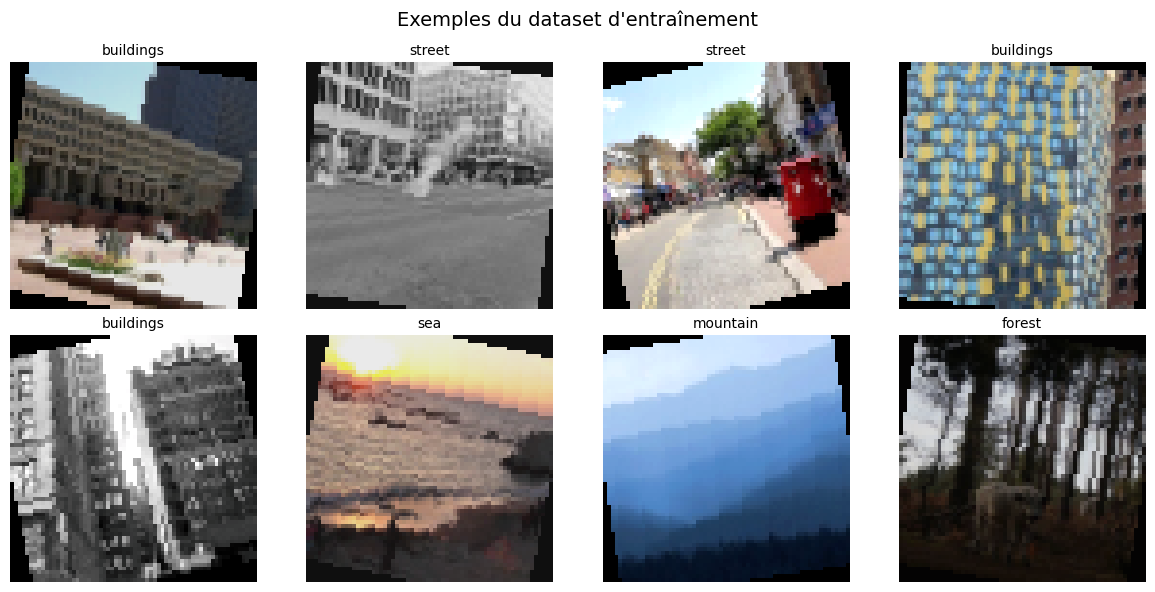

✓ Exemples sauvegardés


In [2]:
# ─────────────────────────────────────────────────────────────
# TRANSFORMATIONS DES IMAGES
# ─────────────────────────────────────────────────────────────

# Transformations pour le jeu d'ENTRAÎNEMENT
# L'augmentation crée des variantes artificielles pour améliorer la généralisation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),      # Redimensionne toutes les images en 64x64
    transforms.RandomHorizontalFlip(p=0.5),       # Retourne horizontalement avec 50% de chance
    transforms.RandomRotation(degrees=15),         # Rotation aléatoire entre -15° et +15°
    transforms.ColorJitter(
        brightness=0.2,                            # Varie la luminosité de ±20%
        contrast=0.2,                              # Varie le contraste de ±20%
        saturation=0.2                             # Varie la saturation de ±20%
    ),
    transforms.ToTensor(),                         # Convertit l'image PIL en tenseur [0,1]
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],               # Soustrait la moyenne de chaque canal RGB
        std=[0.229, 0.224, 0.225]                 # Divise par l'écart-type de chaque canal
    )                                              # Ces valeurs sont standards pour RGB
])

# Transformations pour le jeu de TEST (pas d'augmentation, juste normalisation)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),       # Même taille que le train
    transforms.ToTensor(),                         # Conversion en tenseur
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],               # Même normalisation que le train
        std=[0.229, 0.224, 0.225]                 # (obligatoire pour la cohérence)
    )
])

# ─────────────────────────────────────────────────────────────
# CHARGEMENT DES DATASETS
# ─────────────────────────────────────────────────────────────

# ImageFolder lit automatiquement les dossiers : chaque sous-dossier = une classe
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
test_dataset  = datasets.ImageFolder(root=TEST_DIR,  transform=test_transform)

# Affiche les classes détectées automatiquement
print(f"Classes détectées : {train_dataset.classes}")
print(f"Nombre d'images train : {len(train_dataset)}")
print(f"Nombre d'images test  : {len(test_dataset)}")

# ─────────────────────────────────────────────────────────────
# CRÉATION DES DATALOADERS
# ─────────────────────────────────────────────────────────────

# Le DataLoader charge les images par batchs et les mélange (shuffle)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,  # 32 images par batch
    shuffle=True,            # Mélange aléatoire à chaque epoch (important pour l'apprentissage)
    num_workers=2,           # 2 processus parallèles pour charger les images plus vite
    pin_memory=True          # Accélère le transfert CPU → GPU
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,  # Même taille de batch
    shuffle=False,           # Pas de mélange pour le test (ordre fixe pour évaluation)
    num_workers=2,
    pin_memory=True
)

print(f"Batches train : {len(train_loader)}")
print(f"Batches test  : {len(test_loader)}")

# ─────────────────────────────────────────────────────────────
# VISUALISATION D'EXEMPLES DU DATASET
# ─────────────────────────────────────────────────────────────

# Récupère un batch d'images pour les visualiser
images_sample, labels_sample = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Exemples du dataset d'entraînement", fontsize=14)

for i, ax in enumerate(axes.flatten()):
    if i < 8:
        img = images_sample[i]
        # Dé-normalise pour l'affichage (inverse de la normalisation appliquée)
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        img = img.permute(1, 2, 0).clamp(0, 1)  # Change l'ordre des dimensions pour matplotlib
        ax.imshow(img.numpy())
        ax.set_title(train_dataset.classes[labels_sample[i]], fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Exemples sauvegardés")


## 🧠 Étape 3 — Architecture du CNN (construit from scratch)

In [9]:
# ─────────────────────────────────────────────────────────────
# ARCHITECTURE CNN SIMPLE — SANS FINE-TUNING
# ─────────────────────────────────────────────────────────────
# Toutes les couches sont initialisées aléatoirement et apprises
# depuis zéro sur les données Intel Image Classification.
# ─────────────────────────────────────────────────────────────

class SimpleCNN(nn.Module):
    """
    CNN simple à 4 blocs convolutifs + 2 couches denses.
    Architecture :
        Bloc 1 : Conv(3→32)  + BN + ReLU + MaxPool
        Bloc 2 : Conv(32→64) + BN + ReLU + MaxPool
        Bloc 3 : Conv(64→128)+ BN + ReLU + MaxPool
        Bloc 4 : Conv(128→256)+BN + ReLU + MaxPool
        Classifier : Flatten → FC(1024) → Dropout → FC(6)
    """

    def __init__(self, num_classes=6):
        super(SimpleCNN, self).__init__()

        # ── BLOC CONVOLUTIF 1 ─────────────────────────────────
        # Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        # → entrée : image RGB (3 canaux)
        # → sortie : 32 feature maps (cartes de caractéristiques)
        # padding=1 conserve la taille spatiale (64x64 → 64x64)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # Extraction de 32 features
            nn.BatchNorm2d(32),                            # Normalise les activations → stabilise l'apprentissage
            nn.ReLU(inplace=True),                         # Activation non-linéaire (annule les valeurs négatives)
            nn.MaxPool2d(kernel_size=2, stride=2)          # Réduit de moitié : 64x64 → 32x32
        )

        # ── BLOC CONVOLUTIF 2 ─────────────────────────────────
        # Entrée : 32 feature maps 32x32
        # Sortie : 64 feature maps 16x16
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # Passe de 32 à 64 filtres
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)          # 32x32 → 16x16
        )

        # ── BLOC CONVOLUTIF 3 ─────────────────────────────────
        # Entrée : 64 feature maps 16x16
        # Sortie : 128 feature maps 8x8
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # Passe de 64 à 128 filtres
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)           # 16x16 → 8x8
        )

        # ── BLOC CONVOLUTIF 4 ─────────────────────────────────
        # Entrée : 128 feature maps 8x8
        # Sortie : 256 feature maps 4x4
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),  # Passe de 128 à 256 filtres
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)            # 8x8 → 4x4
        )

        # ── CLASSIFIER (couches entièrement connectées) ───────
        # Après les 4 blocs conv : 256 feature maps de taille 4x4
        # → aplati en vecteur de taille 256 * 4 * 4 = 4096
        self.classifier = nn.Sequential(
            nn.Flatten(),                         # Aplatit le tenseur 3D → vecteur 1D (256*4*4 = 4096)
            nn.Linear(256 * 4 * 4, 1024),        # Couche dense : 4096 → 1024 neurones
            nn.ReLU(inplace=True),                # Activation non-linéaire
            nn.Dropout(p=0.4),                    # Éteint aléatoirement 50% des neurones (régularisation)
            nn.Linear(1024, num_classes)          # Couche de sortie : 1024 → 6 scores (un par classe)
            # Pas de Softmax ici car CrossEntropyLoss l'applique automatiquement
        )

    def forward(self, x):
        """
        Propagation avant : x passe dans les blocs dans l'ordre.
        x : tenseur d'entrée de forme (batch_size, 3, 64, 64)
        """
        x = self.block1(x)       # (B, 3, 64, 64) → (B, 32, 32, 32)
        x = self.block2(x)       # (B, 32, 32, 32) → (B, 64, 16, 16)
        x = self.block3(x)       # (B, 64, 16, 16) → (B, 128, 8, 8)
        x = self.block4(x)       # (B, 128, 8, 8) → (B, 256, 4, 4)
        x = self.classifier(x)   # (B, 256, 4, 4) → (B, 6)
        return x


# ── Instanciation et envoi sur GPU ───────────────────────────
model = SimpleCNN(num_classes=NUM_CLASSES).to(device)

# Affiche l'architecture et le nombre de paramètres
print("=" * 55)
print("        ARCHITECTURE DU CNN PYTORCH")
print("=" * 55)
print(model)

# Calcul du nombre total de paramètres entraînables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParamètres entraînables : {total_params:,}")
print("=" * 55)


        ARCHITECTURE DU CNN PYTORCH
SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(

## 🏋️ Étape 4 — Entraînement du modèle

In [11]:
# ─────────────────────────────────────────────────────────────
# CONFIGURATION DE L'ENTRAÎNEMENT
# ─────────────────────────────────────────────────────────────

# Fonction de perte : CrossEntropyLoss pour la classification multi-classes
# Elle combine LogSoftmax + NLLLoss en une seule opération
criterion = nn.CrossEntropyLoss()

# Optimiseur Adam : adapte le learning rate pour chaque paramètre
# weight_decay = régularisation L2 pour éviter l'overfitting
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Scheduler : réduit le LR de 50% si la val_loss ne s'améliore pas pendant 3 epochs
# → permet une convergence plus fine en fin d'entraînement
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # Surveille la diminution de la perte
    factor=0.5,       # Multiplie le LR par 0.5
    patience=3,       # Attend 3 epochs sans amélioration avant de réduire
    # verbose=True      # Affiche un message quand le LR change
)

# ─────────────────────────────────────────────────────────────
# BOUCLE D'ENTRAÎNEMENT PRINCIPALE
# ─────────────────────────────────────────────────────────────

train_losses = []   # Stocke la perte d'entraînement à chaque epoch
val_losses   = []   # Stocke la perte de validation à chaque epoch
train_accs   = []   # Stocke la précision d'entraînement
val_accs     = []   # Stocke la précision de validation

best_val_acc = 0.0  # Meilleure accuracy de validation (pour sauvegarder le meilleur modèle)

print("Début de l'entraînement...")
print("─" * 65)

for epoch in range(EPOCHS):

    # ── PHASE D'ENTRAÎNEMENT ──────────────────────────────────
    model.train()          # Active le mode entraînement (Dropout actif, BatchNorm en mode train)
    running_loss = 0.0     # Cumule la perte sur tous les batchs
    correct = 0            # Compte les bonnes prédictions
    total   = 0            # Compte le total d'images vues

    for images, labels in train_loader:
        images = images.to(device)    # Envoie les images sur GPU
        labels = labels.to(device)    # Envoie les labels sur GPU

        optimizer.zero_grad()         # Remet les gradients à zéro (évite l'accumulation)

        outputs = model(images)       # Propagation avant : calcule les 6 scores de sortie
        loss = criterion(outputs, labels)  # Calcule la perte entre prédictions et vérités

        loss.backward()               # Rétropropagation : calcule les gradients
        optimizer.step()              # Met à jour les poids du modèle

        running_loss += loss.item()   # Accumule la perte du batch
        _, predicted = torch.max(outputs, 1)   # Prend la classe avec le score le plus élevé
        total   += labels.size(0)     # Ajoute le nombre d'images du batch
        correct += (predicted == labels).sum().item()  # Compte les bonnes prédictions

    # Calcule la perte et précision moyennes sur tout l'epoch
    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total

    # ── PHASE DE VALIDATION ───────────────────────────────────
    model.eval()           # Active le mode évaluation (Dropout désactivé, BatchNorm fixe)
    running_loss = 0.0
    correct = 0
    total   = 0

    with torch.no_grad():  # Désactive le calcul des gradients (économise mémoire et temps)
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)            # Propagation avant sans gradient
            loss = criterion(outputs, labels)  # Calcul de la perte

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(test_loader)
    val_acc  = correct / total

    # ── Mise à jour du scheduler ──────────────────────────────
    scheduler.step(val_loss)   # Réduit le LR si val_loss stagne

    # ── Sauvegarde du meilleur modèle ─────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_model.pth")  # Sauvegarde les poids

    # ── Historique ────────────────────────────────────────────
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc * 100)   # Convertit en pourcentage
    val_accs.append(val_acc * 100)

    # ── Affichage ─────────────────────────────────────────────
    print(f"Epoch [{epoch+1:2d}/{EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%  │  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%")

print("─" * 65)
print(f"✓ Entraînement terminé !  Meilleure Val Accuracy : {best_val_acc*100:.2f}%")


Début de l'entraînement...
─────────────────────────────────────────────────────────────────
Epoch [ 1/25]  Train Loss: 1.1340  Train Acc: 57.97%  │  Val Loss: 0.7500  Val Acc: 72.73%
Epoch [ 2/25]  Train Loss: 0.8367  Train Acc: 69.21%  │  Val Loss: 0.6564  Val Acc: 75.47%
Epoch [ 3/25]  Train Loss: 0.7273  Train Acc: 73.81%  │  Val Loss: 0.5882  Val Acc: 78.80%
Epoch [ 4/25]  Train Loss: 0.6670  Train Acc: 75.99%  │  Val Loss: 0.5315  Val Acc: 81.57%
Epoch [ 5/25]  Train Loss: 0.6308  Train Acc: 77.59%  │  Val Loss: 0.5835  Val Acc: 79.00%
Epoch [ 6/25]  Train Loss: 0.5862  Train Acc: 79.61%  │  Val Loss: 0.5329  Val Acc: 81.23%
Epoch [ 7/25]  Train Loss: 0.5611  Train Acc: 80.26%  │  Val Loss: 0.5297  Val Acc: 82.33%
Epoch [ 8/25]  Train Loss: 0.5379  Train Acc: 80.99%  │  Val Loss: 0.4528  Val Acc: 84.20%
Epoch [ 9/25]  Train Loss: 0.5036  Train Acc: 82.26%  │  Val Loss: 0.4463  Val Acc: 85.37%
Epoch [10/25]  Train Loss: 0.4983  Train Acc: 82.72%  │  Val Loss: 0.4876  Val Acc: 83.3

## 📈 Étape 5 — Visualisation des courbes d'entraînement

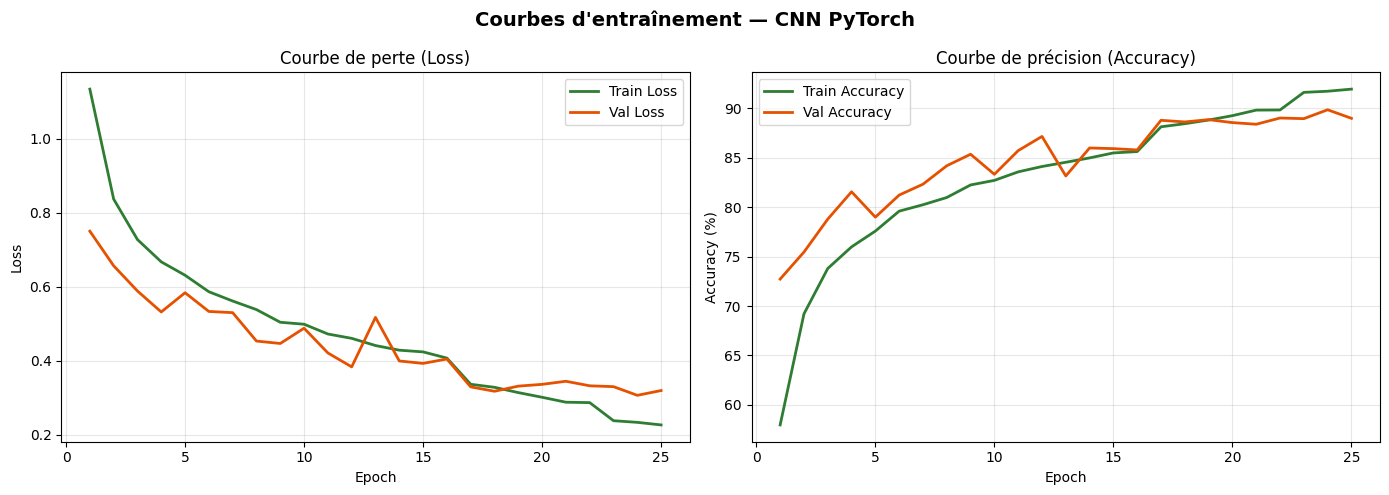

✓ Courbes sauvegardées


In [12]:
# ─────────────────────────────────────────────────────────────
# TRACÉ DES COURBES DE PERTE ET DE PRÉCISION
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Courbes d'entraînement — CNN PyTorch", fontsize=14, fontweight='bold')

# ── Graphique 1 : Loss ────────────────────────────────────────
axes[0].plot(range(1, EPOCHS+1), train_losses,
             label="Train Loss", color="#2E7D32", linewidth=2)    # Vert pour train
axes[0].plot(range(1, EPOCHS+1), val_losses,
             label="Val Loss",   color="#E65100", linewidth=2)    # Orange pour validation
axes[0].set_title("Courbe de perte (Loss)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)  # Grille légère pour faciliter la lecture

# ── Graphique 2 : Accuracy ────────────────────────────────────
axes[1].plot(range(1, EPOCHS+1), train_accs,
             label="Train Accuracy", color="#2E7D32", linewidth=2)
axes[1].plot(range(1, EPOCHS+1), val_accs,
             label="Val Accuracy",   color="#E65100", linewidth=2)
axes[1].set_title("Courbe de précision (Accuracy)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Courbes sauvegardées")


## 🎯 Étape 6 — Évaluation complète du modèle

Accuracy finale sur le jeu de test : 89.87%


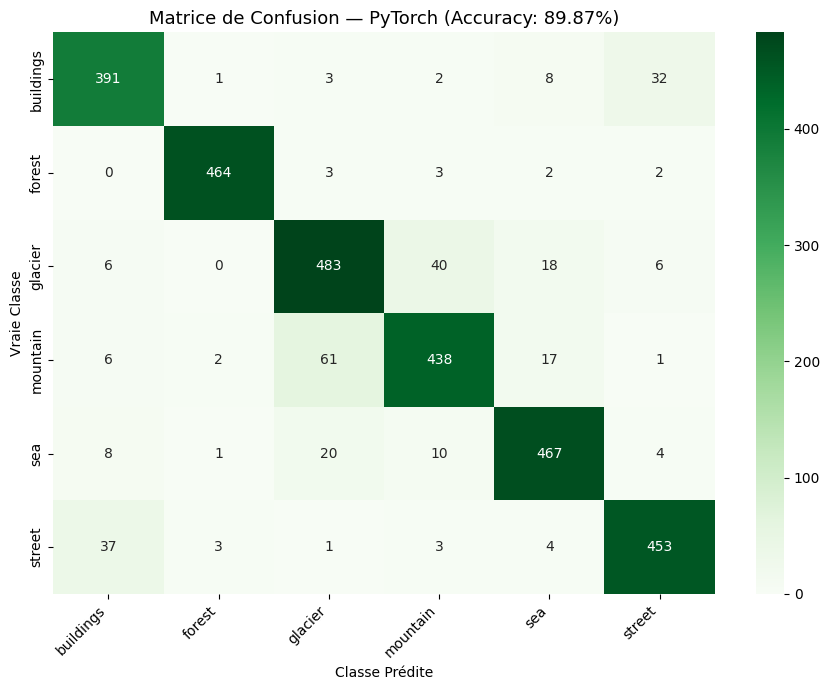

✓ Matrice de confusion sauvegardée


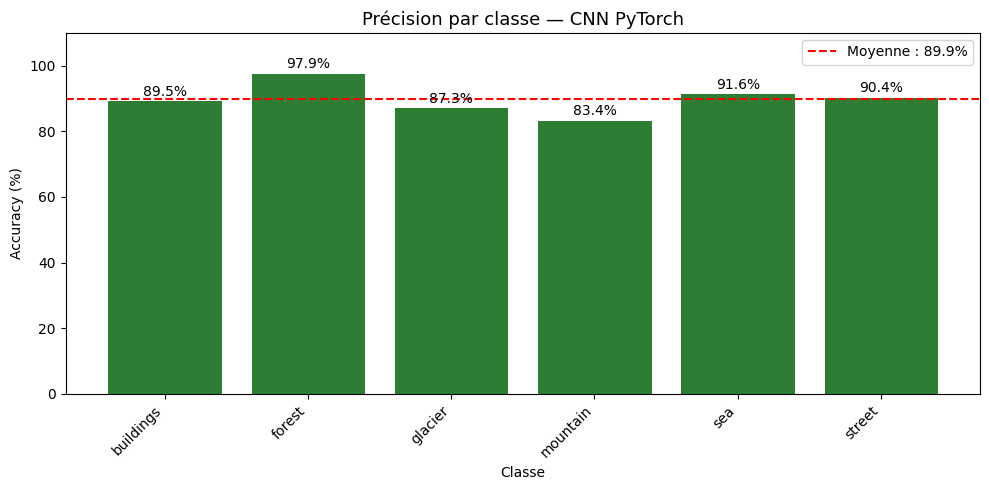

✓ Précision par classe sauvegardée


In [13]:
# ─────────────────────────────────────────────────────────────
# CHARGEMENT DU MEILLEUR MODÈLE ET ÉVALUATION
# ─────────────────────────────────────────────────────────────

# Charge les poids du meilleur modèle sauvegardé pendant l'entraînement
model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model.pth"))
model.eval()   # Mode évaluation : désactive Dropout et BatchNorm en mode train

y_true = []    # Stocke les vraies étiquettes
y_pred = []    # Stocke les prédictions du modèle
correct = 0
total   = 0

with torch.no_grad():   # Pas de calcul de gradient pour l'évaluation
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                    # Calcule les scores pour chaque classe
        _, predicted = torch.max(outputs, 1)       # Prend la classe avec le score max

        y_true.extend(labels.cpu().numpy())        # Convertit en numpy pour sklearn
        y_pred.extend(predicted.cpu().numpy())

        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

# ── Accuracy globale ──────────────────────────────────────────
final_acc = 100 * correct / total
print(f"Accuracy finale sur le jeu de test : {final_acc:.2f}%")

# ─────────────────────────────────────────────────────────────
# MATRICE DE CONFUSION
# ─────────────────────────────────────────────────────────────

cm = confusion_matrix(y_true, y_pred)    # Calcule la matrice de confusion

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,                                  # Affiche les nombres dans chaque cellule
    fmt="d",                                     # Format entier
    cmap="Greens",                               # Palette de couleurs verte
    xticklabels=train_dataset.classes,           # Labels des colonnes (prédictions)
    yticklabels=train_dataset.classes            # Labels des lignes (vraies classes)
)
plt.title(f"Matrice de Confusion — PyTorch (Accuracy: {final_acc:.2f}%)", fontsize=13)
plt.xlabel("Classe Prédite")
plt.ylabel("Vraie Classe")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Matrice de confusion sauvegardée")

# ─────────────────────────────────────────────────────────────
# PRÉCISION PAR CLASSE
# ─────────────────────────────────────────────────────────────

# Calcule la précision pour chaque classe individuellement
correct_per_class = np.zeros(NUM_CLASSES)
total_per_class   = np.zeros(NUM_CLASSES)

for i in range(len(y_true)):
    total_per_class[y_true[i]] += 1                        # Compte le total par classe
    if y_true[i] == y_pred[i]:
        correct_per_class[y_true[i]] += 1                 # Compte les bonnes prédictions

class_acc = 100 * correct_per_class / total_per_class     # Précision en pourcentage

plt.figure(figsize=(10, 5))
bars = plt.bar(train_dataset.classes, class_acc, color="#2E7D32", edgecolor='white', linewidth=0.7)
plt.axhline(y=final_acc, color='red', linestyle='--', label=f'Moyenne : {final_acc:.1f}%')

# Affiche la valeur au-dessus de chaque barre
for bar, acc in zip(bars, class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{acc:.1f}%", ha='center', va='bottom', fontsize=10)

plt.title("Précision par classe — CNN PyTorch", fontsize=13)
plt.xlabel("Classe")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/accuracy_per_class.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Précision par classe sauvegardée")


## 📋 Étape 7 — Rapport de classification et exemples de prédictions

Rapport de classification :
              precision    recall  f1-score   support

   buildings       0.87      0.89      0.88       437
      forest       0.99      0.98      0.98       474
     glacier       0.85      0.87      0.86       553
    mountain       0.88      0.83      0.86       525
         sea       0.91      0.92      0.91       510
      street       0.91      0.90      0.91       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000

✓ Rapport sauvegardé dans pytorch_model/classification_report.txt


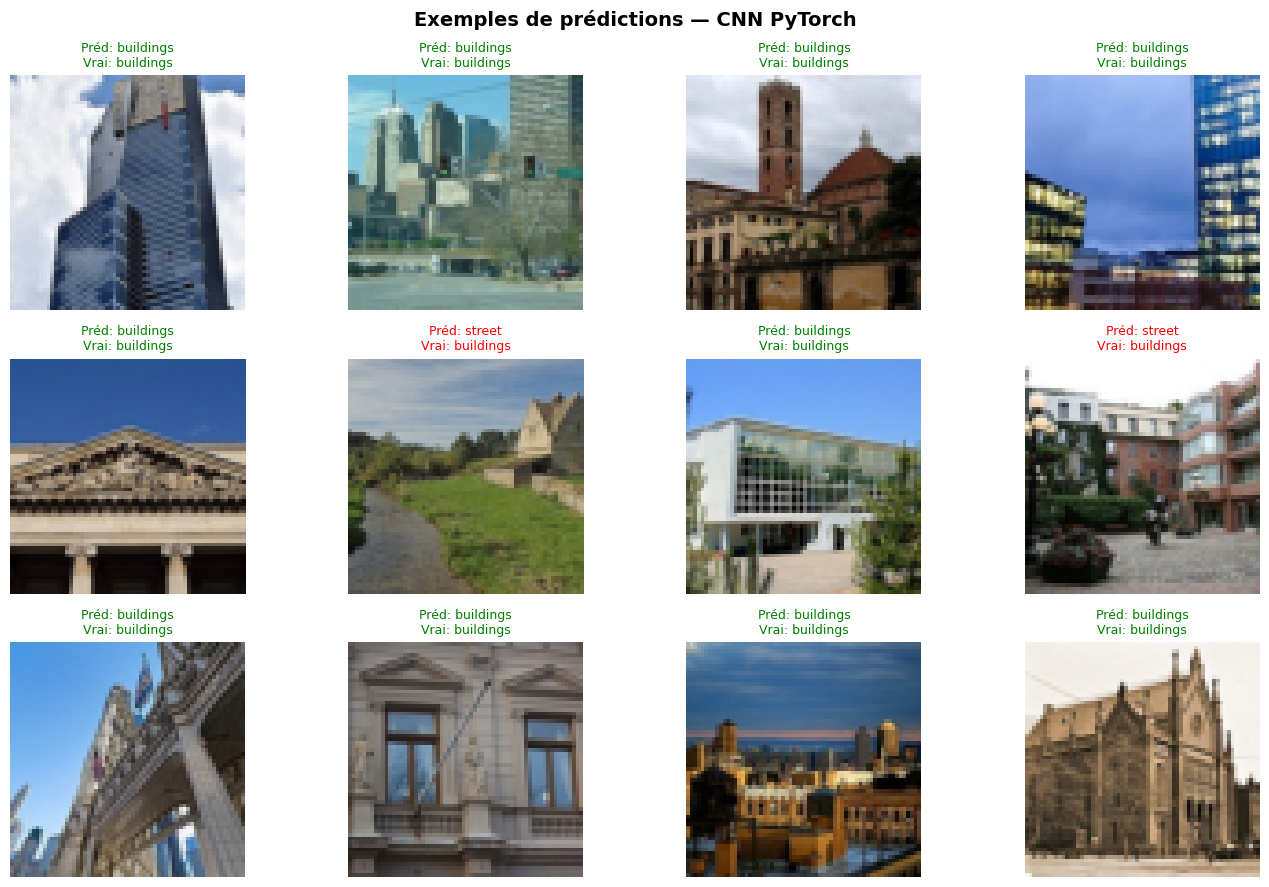

✓ Exemples de prédictions sauvegardés

✓ Modèle PyTorch sauvegardé : pytorch_model/cnn_intel_pytorch.pth
  Accuracy finale : 89.87%


In [14]:
# ─────────────────────────────────────────────────────────────
# RAPPORT DE CLASSIFICATION DÉTAILLÉ
# ─────────────────────────────────────────────────────────────

# Génère un tableau avec Précision, Rappel, F1-score pour chaque classe
report = classification_report(
    y_true, y_pred,
    target_names=train_dataset.classes   # Remplace les indices par les noms de classes
)
print("Rapport de classification :")
print(report)

# Sauvegarde le rapport dans un fichier texte
with open(f"{SAVE_DIR}/classification_report.txt", "w") as f:
    f.write("RAPPORT DE CLASSIFICATION — CNN PYTORCH\n")
    f.write("=" * 50 + "\n")
    f.write(report)
print(f"✓ Rapport sauvegardé dans {SAVE_DIR}/classification_report.txt")

# ─────────────────────────────────────────────────────────────
# EXEMPLES DE PRÉDICTIONS VISUELLES
# ─────────────────────────────────────────────────────────────

# Récupère un batch du test_loader pour visualiser les prédictions
images_batch, labels_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

outputs_batch = model(images_batch)           # Calcule les scores
_, preds_batch = torch.max(outputs_batch, 1)  # Prend la classe avec le score max

class_names = train_dataset.classes           # Liste des noms de classes

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle("Exemples de prédictions — CNN PyTorch", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    if i < 12:
        img = images_batch[i].cpu()

        # Dé-normalise l'image pour l'affichage correct
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        img = img.permute(1, 2, 0).clamp(0, 1).numpy()  # HxWxC, valeurs [0,1]

        ax.imshow(img)

        pred_name  = class_names[preds_batch[i]]        # Classe prédite
        true_name  = class_names[labels_batch[i]]       # Vraie classe

        # Titre vert si correct, rouge si incorrect
        color = "green" if pred_name == true_name else "red"
        ax.set_title(f"Préd: {pred_name}\nVrai: {true_name}", fontsize=9, color=color)
        ax.axis('off')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/predictions_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Exemples de prédictions sauvegardés")

# ─────────────────────────────────────────────────────────────
# SAUVEGARDE FINALE DU MODÈLE
# ─────────────────────────────────────────────────────────────

# Sauvegarde les poids du modèle final
torch.save(model.state_dict(), f"{SAVE_DIR}/cnn_intel_pytorch.pth")
print(f"\n✓ Modèle PyTorch sauvegardé : {SAVE_DIR}/cnn_intel_pytorch.pth")
print(f"  Accuracy finale : {final_acc:.2f}%")


---
---
# 🟠 PARTIE 2 — TENSORFLOW / KERAS
### Le même CNN simple, version TensorFlow (sans fine-tuning)
---


## 📦 Étape 1 TF — Imports TensorFlow

In [32]:
# ─────────────────────────────────────────────────────────────
# IMPORTS TENSORFLOW / KERAS
# ─────────────────────────────────────────────────────────────

import tensorflow as tf                               # Framework deep learning Google
from tensorflow import keras                          # API haut niveau de TensorFlow
from tensorflow.keras import layers, models           # Couches et modèles Keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Augmentation images
from tensorflow.keras.callbacks import (
    ModelCheckpoint,       # Sauvegarde le meilleur modèle automatiquement
    ReduceLROnPlateau,     # Réduit le LR si la perte stagne
    EarlyStopping          # Arrête l'entraînement si pas d'amélioration
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ── Vérification GPU TensorFlow ───────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU disponibles : {gpus}")
print(f"Version TensorFlow : {tf.__version__}")

# ── Paramètres (identiques à PyTorch pour comparaison équitable) ──
TF_IMG_SIZE   = 64       # Taille des images 64x64
TF_BATCH_SIZE = 32       # Taille des batchs
TF_EPOCHS     = 25       # Nombre d'epochs
TF_LR         = 0.0005    # Learning rate initial
TF_NUM_CLASSES= 6        # Nombre de classes
TF_SAVE_DIR   = "tensorflow_model"   # Dossier de sauvegarde

os.makedirs(TF_SAVE_DIR, exist_ok=True)   # Crée le dossier s'il n'existe pas
print(f"Dossier TensorFlow : {TF_SAVE_DIR}")


GPU disponibles : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Version TensorFlow : 2.19.0
Dossier TensorFlow : tensorflow_model


## 🔄 Étape 2 TF — Préparation des données avec ImageDataGenerator

In [33]:
# ─────────────────────────────────────────────────────────────
# GÉNÉRATEUR DE DONNÉES TENSORFLOW
# ─────────────────────────────────────────────────────────────
# Keras utilise ImageDataGenerator pour charger et augmenter les images
# directement depuis les dossiers (équivalent de ImageFolder en PyTorch)
# ─────────────────────────────────────────────────────────────

# Générateur pour l'ENTRAÎNEMENT avec augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalise les pixels de [0,255] → [0,1]
    horizontal_flip=True,        # Retournement horizontal aléatoire
    rotation_range=15,           # Rotation aléatoire ±15 degrés
    width_shift_range=0.1,       # Décalage horizontal de ±10% de la largeur
    height_shift_range=0.1,      # Décalage vertical de ±10% de la hauteur
    zoom_range=0.1,              # Zoom aléatoire de ±10%
    brightness_range=[0.8, 1.2], # Variation de la luminosité entre 80% et 120%
    fill_mode='nearest'          # Remplit les pixels manquants par le plus proche voisin
)

# Générateur pour le TEST (seulement normalisation, pas d'augmentation)
test_datagen = ImageDataGenerator(
    rescale=1./255               # Même normalisation que le train
)

# ── Chargement des images depuis les dossiers ─────────────────
# flow_from_directory lit automatiquement les sous-dossiers comme classes
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,                           # Dossier contenant les classes
    target_size=(TF_IMG_SIZE, TF_IMG_SIZE),  # Redimensionne toutes les images
    batch_size=TF_BATCH_SIZE,            # 32 images par batch
    class_mode='sparse',                 # Labels entiers (0,1,2,3,4,5) pour sparse_crossentropy
    shuffle=True                         # Mélange les images à chaque epoch
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(TF_IMG_SIZE, TF_IMG_SIZE),
    batch_size=TF_BATCH_SIZE,
    class_mode='sparse',
    shuffle=False                        # Pas de mélange pour avoir un ordre fixe à l'évaluation
)

# Affiche les informations du dataset
print(f"Classes détectées : {list(train_generator.class_indices.keys())}")
print(f"Nombre d'images train : {train_generator.samples}")
print(f"Nombre d'images test  : {test_generator.samples}")
print(f"Nombre de batchs train : {len(train_generator)}")


Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Classes détectées : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Nombre d'images train : 14034
Nombre d'images test  : 3000
Nombre de batchs train : 439


## 🧠 Étape 3 TF — Architecture CNN TensorFlow (identique à PyTorch)

In [34]:
# ─────────────────────────────────────────────────────────────
# CONSTRUCTION DU CNN AVEC KERAS — MÊME ARCHITECTURE QUE PYTORCH
# ─────────────────────────────────────────────────────────────
# On utilise l'API Séquentielle de Keras (équivalent nn.Sequential de PyTorch)
# L'architecture est identique au CNN PyTorch pour une comparaison juste
# ─────────────────────────────────────────────────────────────

def build_cnn(input_shape=(64, 64, 3), num_classes=6):
    """
    Construit un CNN simple identique à SimpleCNN (PyTorch).
    Architecture :
        Bloc 1 : Conv(32)  + BN + ReLU + MaxPool
        Bloc 2 : Conv(64)  + BN + ReLU + MaxPool
        Bloc 3 : Conv(128) + BN + ReLU + MaxPool
        Bloc 4 : Conv(256) + BN + ReLU + MaxPool
        Classifier : Flatten → Dense(1024) → Dropout(0.5) → Dense(6)
    """
    model = models.Sequential([

        # ── BLOC CONVOLUTIF 1 ─────────────────────────────────
        # Conv2D(32 filtres, kernel 3x3, padding 'same' conserve la taille)
        # input_shape : premier bloc doit spécifier la forme d'entrée
        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),         # Normalise les activations (stabilité)
        layers.Activation('relu'),           # ReLU : max(0, x) — supprime les valeurs négatives
        layers.MaxPooling2D((2, 2)),         # Réduit de moitié : 64x64 → 32x32

        # ── BLOC CONVOLUTIF 2 ─────────────────────────────────
        layers.Conv2D(64, (3, 3), padding='same'),   # 32 → 64 filtres
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),                 # 32x32 → 16x16

        # ── BLOC CONVOLUTIF 3 ─────────────────────────────────
        layers.Conv2D(128, (3, 3), padding='same'),  # 64 → 128 filtres
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),                 # 16x16 → 8x8

        # ── BLOC CONVOLUTIF 4 ─────────────────────────────────
        layers.Conv2D(256, (3, 3), padding='same'),  # 128 → 256 filtres
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),                 # 8x8 → 4x4

        # ── CLASSIFIER ───────────────────────────────────────
        layers.Flatten(),                            # Aplatit 4x4x256 → vecteur de 4096
        layers.Dense(1024, activation='relu'),       # Couche dense : 4096 → 1024 neurones
        layers.Dropout(0.4),                         # Éteint 50% des neurones (régularisation)
        layers.Dense(num_classes, activation='softmax')  # Couche de sortie avec Softmax
        # Softmax convertit les scores en probabilités (somme = 1)
        # (En PyTorch, le Softmax était dans la loss ; ici on l'applique explicitement)
    ])
    return model

# ── Instanciation et compilation ──────────────────────────────
tf_model = build_cnn(input_shape=(TF_IMG_SIZE, TF_IMG_SIZE, 3), num_classes=TF_NUM_CLASSES)

# Compilation : définit la loss, l'optimiseur et les métriques
tf_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=TF_LR),  # Adam avec LR initial
    loss='sparse_categorical_crossentropy',                  # Loss pour labels entiers (0,1,2...)
    metrics=['accuracy']                                     # Affiche l'accuracy pendant l'entraînement
)

# Affiche le résumé du modèle : couches, formes, paramètres
print("=" * 55)
print("    ARCHITECTURE DU CNN TENSORFLOW")
print("=" * 55)
tf_model.summary()


    ARCHITECTURE DU CNN TENSORFLOW


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,591,814 (17.52 MB)

 Trainable params: 4,590,854 (17.51 MB)

 Non-trainable params: 960 (3.75 KB)

## 🏋️ Étape 4 TF — Entraînement TensorFlow

In [35]:
# ─────────────────────────────────────────────────────────────
# CALLBACKS : actions automatiques pendant l'entraînement
# ─────────────────────────────────────────────────────────────

callbacks = [

    # Sauvegarde le modèle quand val_accuracy s'améliore
    ModelCheckpoint(
        filepath=f"{TF_SAVE_DIR}/best_model.keras",  # Chemin de sauvegarde
        monitor='val_accuracy',                       # Surveille la val_accuracy
        save_best_only=True,                          # Sauvegarde seulement si amélioration
        verbose=1                                     # Affiche un message quand il sauvegarde
    ),

    # Réduit le learning rate si val_loss stagne pendant 3 epochs
    ReduceLROnPlateau(
        monitor='val_loss',   # Surveille la perte de validation
        factor=0.5,           # Multiplie le LR par 0.5 (le divise par 2)
        patience=3,           # Attend 3 epochs sans amélioration
        min_lr=1e-6,          # Learning rate minimum
        verbose=1             # Affiche un message quand le LR change
    ),

    # Arrête l'entraînement si val_loss ne s'améliore pas pendant 7 epochs
    EarlyStopping(
        monitor='val_loss',   # Surveille la perte de validation
        patience=7,           # Attend 7 epochs avant d'arrêter
        restore_best_weights=True,  # Restaure les poids du meilleur epoch
        verbose=1
    )
]

# ─────────────────────────────────────────────────────────────
# LANCEMENT DE L'ENTRAÎNEMENT
# ─────────────────────────────────────────────────────────────

print("Début de l'entraînement TensorFlow...")
print("─" * 55)

# model.fit : boucle d'entraînement complète
# Keras gère automatiquement train/val, les callbacks, et l'historique
history = tf_model.fit(
    train_generator,                     # Données d'entraînement (avec augmentation)
    epochs=TF_EPOCHS,                    # Nombre d'epochs maximum
    validation_data=test_generator,      # Données de validation pour surveiller l'overfitting
    callbacks=callbacks,                 # Liste des callbacks définis ci-dessus
    verbose=1                            # Affiche la progression à chaque epoch
)

print("─" * 55)
print("✓ Entraînement TensorFlow terminé !")


Début de l'entraînement TensorFlow...
───────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5247 - loss: 1.7431
Epoch 1: val_accuracy improved from -inf to 0.61233, saving model to tensorflow_model/best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 60s 120ms/step - accuracy: 0.5249 - loss: 1.7417 - val_accuracy: 0.6123 - val_loss: 0.8895 - learning_rate: 5.0000e-04
Epoch 2/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7065 - loss: 0.7894
Epoch 2: val_accuracy improved from 0.61233 to 0.77600, saving model to tensorflow_model/best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 48s 108ms/step - accuracy: 0.7065 - loss: 0.7893 - val_accuracy: 0.7760 - val_loss: 0.6145 - learning_rate: 5.0000e-04
Epoch 3/25
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7469 - loss: 0.7010
Epoch 3: val_accuracy did not improve from 0.77600
439/439 ━━━━━━━━━━━━━━━━━━━━ 47s 107ms/step - accuracy: 0.7470 - loss: 0.7009 - val_accuracy: 0.7483 - val_loss: 0.6376 - learning_rate: 5.0000e-04
Epoch 4/25
439/439 ━━━━━━━━━━━━━━━

## 📈 Étape 5 TF — Visualisation des courbes TensorFlow

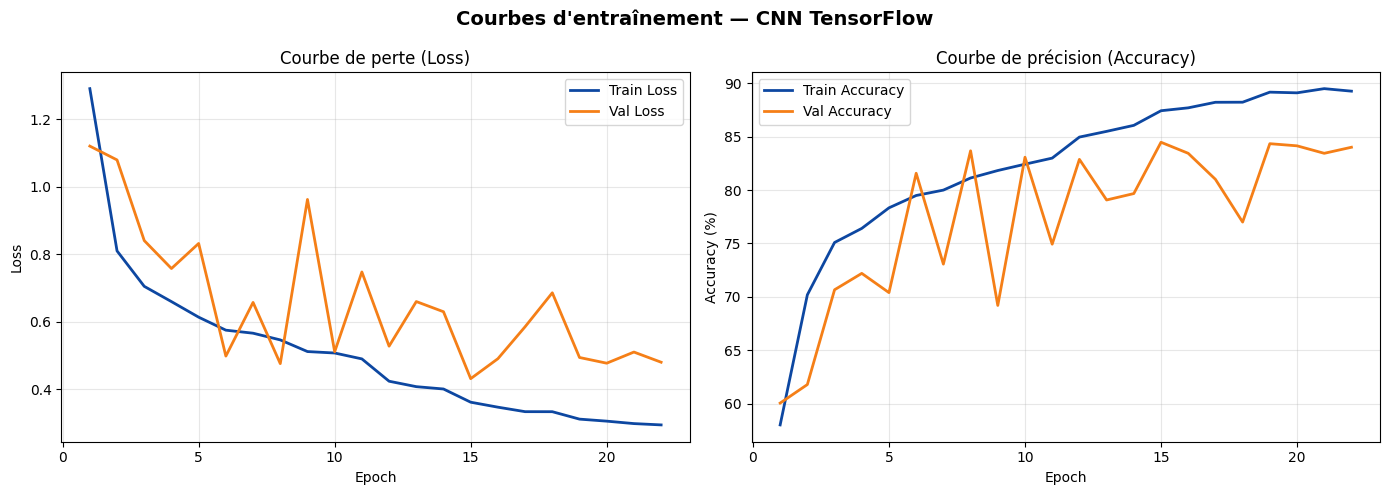

✓ Courbes TensorFlow sauvegardées


In [29]:
# ─────────────────────────────────────────────────────────────
# TRACÉ DES COURBES D'ENTRAÎNEMENT TensorFlow
# ─────────────────────────────────────────────────────────────
# history.history contient le dictionnaire de toutes les métriques
# enregistrées à chaque epoch par Keras
# ─────────────────────────────────────────────────────────────

tf_train_loss = history.history['loss']          # Perte d'entraînement à chaque epoch
tf_val_loss   = history.history['val_loss']      # Perte de validation
tf_train_acc  = history.history['accuracy']      # Précision d'entraînement
tf_val_acc    = history.history['val_accuracy']  # Précision de validation

nb_epochs_run = len(tf_train_loss)   # Nombre réel d'epochs (peut être < TF_EPOCHS si EarlyStopping)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Courbes d'entraînement — CNN TensorFlow", fontsize=14, fontweight='bold')

# ── Graphique Loss ────────────────────────────────────────────
axes[0].plot(range(1, nb_epochs_run+1), tf_train_loss,
             label="Train Loss", color="#0D47A1", linewidth=2)    # Bleu pour TF
axes[0].plot(range(1, nb_epochs_run+1), tf_val_loss,
             label="Val Loss",   color="#F57F17", linewidth=2)    # Jaune pour validation
axes[0].set_title("Courbe de perte (Loss)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Graphique Accuracy ────────────────────────────────────────
axes[1].plot(range(1, nb_epochs_run+1), [a*100 for a in tf_train_acc],
             label="Train Accuracy", color="#0D47A1", linewidth=2)
axes[1].plot(range(1, nb_epochs_run+1), [a*100 for a in tf_val_acc],
             label="Val Accuracy",   color="#F57F17", linewidth=2)
axes[1].set_title("Courbe de précision (Accuracy)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{TF_SAVE_DIR}/training_curves_tf.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Courbes TensorFlow sauvegardées")


## 🎯 Étape 6 TF — Évaluation complète TensorFlow

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8019 - loss: 0.5494

Accuracy finale TensorFlow : 84.47%
Perte finale TensorFlow    : 0.4316
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step


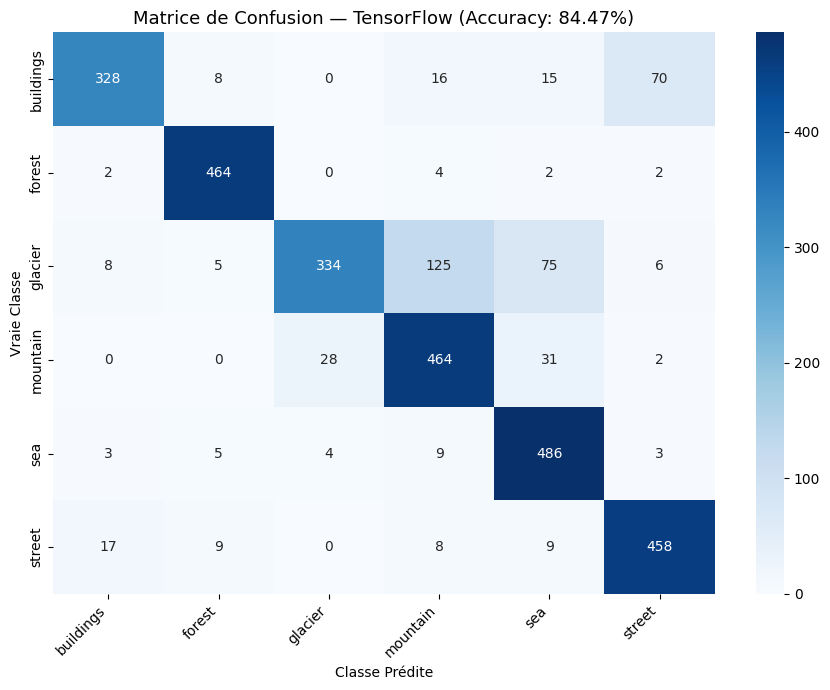

✓ Matrice de confusion TensorFlow sauvegardée


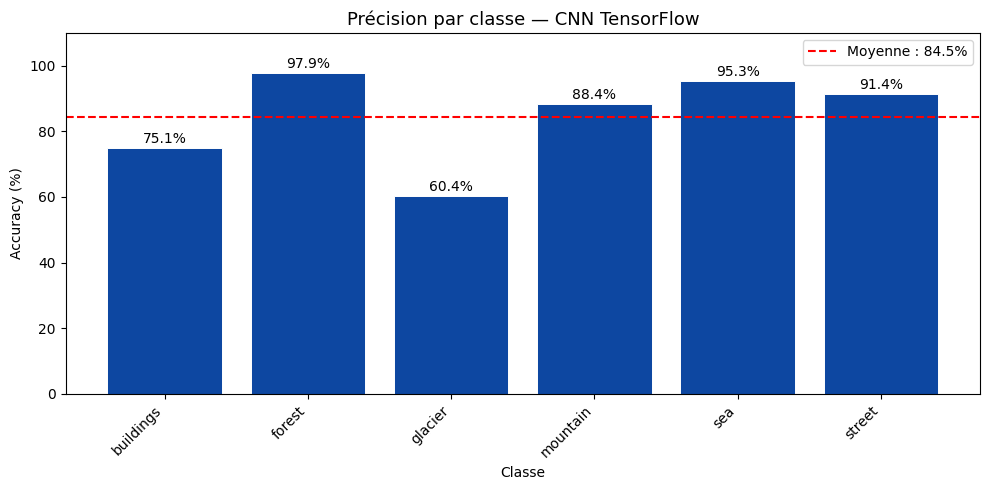

✓ Précision par classe TensorFlow sauvegardée


In [30]:
# ─────────────────────────────────────────────────────────────
# ÉVALUATION FINALE SUR LE JEU DE TEST
# ─────────────────────────────────────────────────────────────

# Évaluation rapide avec model.evaluate (retourne loss + accuracy)
test_loss, test_acc = tf_model.evaluate(test_generator, verbose=1)
print(f"\nAccuracy finale TensorFlow : {test_acc*100:.2f}%")
print(f"Perte finale TensorFlow    : {test_loss:.4f}")

# ─────────────────────────────────────────────────────────────
# PRÉDICTIONS POUR MATRICE DE CONFUSION
# ─────────────────────────────────────────────────────────────

# Réinitialise le générateur pour parcourir tout le dataset
test_generator.reset()

# model.predict retourne les probabilités softmax pour chaque image
y_proba = tf_model.predict(test_generator, verbose=1)

# Prend la classe avec la probabilité la plus élevée (argmax)
y_pred_tf = np.argmax(y_proba, axis=1)

# Récupère les vraies étiquettes depuis le générateur
y_true_tf = test_generator.classes

# Récupère les noms des classes depuis l'index du générateur
class_names_tf = list(train_generator.class_indices.keys())

# ─────────────────────────────────────────────────────────────
# MATRICE DE CONFUSION
# ─────────────────────────────────────────────────────────────

cm_tf = confusion_matrix(y_true_tf, y_pred_tf)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_tf,
    annot=True,                      # Affiche les valeurs dans les cellules
    fmt="d",                         # Format entier
    cmap="Blues",                    # Palette bleue (couleur TensorFlow)
    xticklabels=class_names_tf,      # Noms des colonnes
    yticklabels=class_names_tf       # Noms des lignes
)
plt.title(f"Matrice de Confusion — TensorFlow (Accuracy: {test_acc*100:.2f}%)", fontsize=13)
plt.xlabel("Classe Prédite")
plt.ylabel("Vraie Classe")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{TF_SAVE_DIR}/confusion_matrix_tf.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Matrice de confusion TensorFlow sauvegardée")

# ─────────────────────────────────────────────────────────────
# PRÉCISION PAR CLASSE
# ─────────────────────────────────────────────────────────────

correct_tf = np.zeros(TF_NUM_CLASSES)
total_tf   = np.zeros(TF_NUM_CLASSES)

for i in range(len(y_true_tf)):
    total_tf[y_true_tf[i]] += 1                       # Total par classe
    if y_true_tf[i] == y_pred_tf[i]:
        correct_tf[y_true_tf[i]] += 1                 # Bonnes prédictions par classe

class_acc_tf = 100 * correct_tf / total_tf            # Précision en %

plt.figure(figsize=(10, 5))
bars = plt.bar(class_names_tf, class_acc_tf,
               color="#0D47A1", edgecolor='white', linewidth=0.7)
plt.axhline(y=test_acc*100, color='red', linestyle='--',
            label=f'Moyenne : {test_acc*100:.1f}%')

for bar, acc in zip(bars, class_acc_tf):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{acc:.1f}%", ha='center', va='bottom', fontsize=10)

plt.title("Précision par classe — CNN TensorFlow", fontsize=13)
plt.xlabel("Classe")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(f"{TF_SAVE_DIR}/accuracy_per_class_tf.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Précision par classe TensorFlow sauvegardée")


## 📋 Étape 7 TF — Rapport + Comparaison PyTorch vs TensorFlow

Rapport de classification TensorFlow :
              precision    recall  f1-score   support

   buildings       0.92      0.75      0.83       437
      forest       0.95      0.98      0.96       474
     glacier       0.91      0.60      0.73       553
    mountain       0.74      0.88      0.81       525
         sea       0.79      0.95      0.86       510
      street       0.85      0.91      0.88       501

    accuracy                           0.84      3000
   macro avg       0.86      0.85      0.84      3000
weighted avg       0.86      0.84      0.84      3000

✓ Rapport sauvegardé dans tensorflow_model/classification_report_tf.txt

     COMPARAISON PYTORCH vs TENSORFLOW
  PyTorch    — Accuracy : 89.87%
  TensorFlow — Accuracy : 84.47%
───────────────────────────────────────────────────────
  Même architecture CNN, même dataset, mêmes hyperparamètres
  Les différences viennent de l'initialisation aléatoire


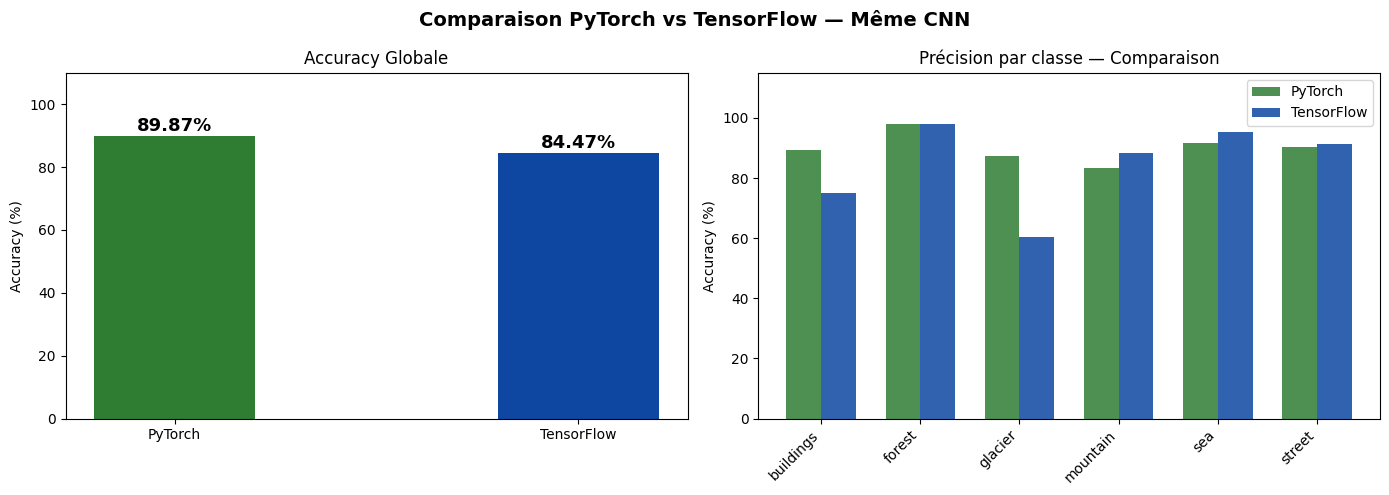

✓ Comparaison sauvegardée : comparison_pytorch_tensorflow.png

✓ Modèle TensorFlow sauvegardé : tensorflow_model/cnn_intel_tensorflow.keras

     FICHIERS GÉNÉRÉS
📁 pytorch_model/
   ├── best_model.pth              (meilleur modèle PyTorch)
   ├── cnn_intel_pytorch.pth       (modèle final PyTorch)
   ├── training_curves.png         (courbes PyTorch)
   ├── confusion_matrix.png        (matrice de confusion PyTorch)
   ├── accuracy_per_class.png      (précision par classe PyTorch)
   ├── predictions_samples.png     (exemples de prédictions)
   └── classification_report.txt  (rapport détaillé)

📁 tensorflow_model/
   ├── best_model.keras            (meilleur modèle TensorFlow)
   ├── cnn_intel_tensorflow.keras  (modèle final TensorFlow)
   ├── training_curves_tf.png      (courbes TensorFlow)
   ├── confusion_matrix_tf.png     (matrice de confusion TF)
   ├── accuracy_per_class_tf.png   (précision par classe TF)
   └── classification_report_tf.txt

📊 comparison_pytorch_tensorflow.png  (com

In [31]:
# ─────────────────────────────────────────────────────────────
# RAPPORT DE CLASSIFICATION TENSORFLOW
# ─────────────────────────────────────────────────────────────

report_tf = classification_report(
    y_true_tf, y_pred_tf,
    target_names=class_names_tf   # Remplace les indices par les noms de classes
)
print("Rapport de classification TensorFlow :")
print(report_tf)

# Sauvegarde le rapport dans un fichier texte
with open(f"{TF_SAVE_DIR}/classification_report_tf.txt", "w") as f:
    f.write("RAPPORT DE CLASSIFICATION — CNN TENSORFLOW\n")
    f.write("=" * 50 + "\n")
    f.write(report_tf)
print(f"✓ Rapport sauvegardé dans {TF_SAVE_DIR}/classification_report_tf.txt")

# ─────────────────────────────────────────────────────────────
# COMPARAISON PYTORCH vs TENSORFLOW
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 55)
print("     COMPARAISON PYTORCH vs TENSORFLOW")
print("=" * 55)
print(f"  PyTorch    — Accuracy : {final_acc:.2f}%")
print(f"  TensorFlow — Accuracy : {test_acc*100:.2f}%")
print("─" * 55)
print("  Même architecture CNN, même dataset, mêmes hyperparamètres")
print("  Les différences viennent de l'initialisation aléatoire")
print("=" * 55)

# ─────────────────────────────────────────────────────────────
# VISUALISATION COMPARATIVE
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaison PyTorch vs TensorFlow — Même CNN", fontsize=14, fontweight='bold')

# ── Accuracy par framework ────────────────────────────────────
frameworks = ['PyTorch', 'TensorFlow']
accuracies  = [final_acc, test_acc * 100]
colors_cmp  = ['#2E7D32', '#0D47A1']    # Vert PyTorch, Bleu TensorFlow

bars_cmp = axes[0].bar(frameworks, accuracies, color=colors_cmp, width=0.4)
for bar, acc in zip(bars_cmp, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{acc:.2f}%", ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_title("Accuracy Globale")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 110)

# ── Précision par classe : PyTorch vs TensorFlow ──────────────
x = np.arange(len(class_names_tf))
width = 0.35

bars1 = axes[1].bar(x - width/2, class_acc,    width, label='PyTorch',    color='#2E7D32', alpha=0.85)
bars2 = axes[1].bar(x + width/2, class_acc_tf, width, label='TensorFlow', color='#0D47A1', alpha=0.85)

axes[1].set_title("Précision par classe — Comparaison")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names_tf, rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim(0, 115)

plt.tight_layout()
plt.savefig("comparison_pytorch_tensorflow.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Comparaison sauvegardée : comparison_pytorch_tensorflow.png")

# ─────────────────────────────────────────────────────────────
# SAUVEGARDE FINALE DU MODÈLE TENSORFLOW
# ─────────────────────────────────────────────────────────────

# Sauvegarde en format SavedModel (format natif TensorFlow)
tf_model.save(f"{TF_SAVE_DIR}/cnn_intel_tensorflow.keras")
print(f"\n✓ Modèle TensorFlow sauvegardé : {TF_SAVE_DIR}/cnn_intel_tensorflow.keras")

# ─────────────────────────────────────────────────────────────
# RÉSUMÉ FINAL DES FICHIERS GÉNÉRÉS
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 55)
print("     FICHIERS GÉNÉRÉS")
print("=" * 55)
print(f"📁 {SAVE_DIR}/")
print(f"   ├── best_model.pth              (meilleur modèle PyTorch)")
print(f"   ├── cnn_intel_pytorch.pth       (modèle final PyTorch)")
print(f"   ├── training_curves.png         (courbes PyTorch)")
print(f"   ├── confusion_matrix.png        (matrice de confusion PyTorch)")
print(f"   ├── accuracy_per_class.png      (précision par classe PyTorch)")
print(f"   ├── predictions_samples.png     (exemples de prédictions)")
print(f"   └── classification_report.txt  (rapport détaillé)")
print(f"\n📁 {TF_SAVE_DIR}/")
print(f"   ├── best_model.keras            (meilleur modèle TensorFlow)")
print(f"   ├── cnn_intel_tensorflow.keras  (modèle final TensorFlow)")
print(f"   ├── training_curves_tf.png      (courbes TensorFlow)")
print(f"   ├── confusion_matrix_tf.png     (matrice de confusion TF)")
print(f"   ├── accuracy_per_class_tf.png   (précision par classe TF)")
print(f"   └── classification_report_tf.txt")
print(f"\n📊 comparison_pytorch_tensorflow.png  (comparaison globale)")
print("=" * 55)
